In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

In [70]:
df = pd.read_csv("online food delivery dataset.csv", sep=";")
df.head(10)

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback,Unnamed: 13
0,20,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9766,77.5993,560001.0,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,Regular,12.9770,77.5773,NaN,Yes,Positive,Yes
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,Regular,12.9551,77.6593,560017.0,Yes,Negative,Yes
3,22,Female,Single,Student,No Income,Graduate,6,Frequent,12.9473,77.5616,560019.0,Yes,Positive,Yes
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,Frequent,12.9850,77.5533,560010.0,Yes,Positive,Yes
5,27,Female,Married,Employee,More than 50000,Post Graduate,2,Regular,12.9299,77.6848,560103.0,Yes,Positive,Yes
6,22,Male,Single,Student,No Income,Graduate,3,Regular,12.9770,77.5773,560009.0,Yes,Positive,Yes
7,24,Female,Single,Student,No Income,Post Graduate,3,Regular,12.9828,77.6131,NaN,Yes,Positive,Yes
8,23,Female,Single,Student,No Income,Post Graduate,2,Regular,12.9766,77.5993,560001.0,Yes,Positive,Yes
9,23,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9854,77.7081,560048.0,Yes,Positive,Yes


In [71]:
df.dtypes

Age                             int64
Gender                            str
Marital Status                    str
Occupation                        str
Monthly Income                    str
Educational Qualifications        str
Family size                     int64
Customer Type                     str
latitude                      float64
longitude                     float64
Pin code                      float64
Output                            str
Feedback                          str
Unnamed: 13                       str
dtype: object

In [72]:
df = df.drop(columns=['Unnamed: 13'])
df['Feedback'] = df['Feedback'].str.strip()
df.dtypes

Age                             int64
Gender                            str
Marital Status                    str
Occupation                        str
Monthly Income                    str
Educational Qualifications        str
Family size                     int64
Customer Type                     str
latitude                      float64
longitude                     float64
Pin code                      float64
Output                            str
Feedback                          str
dtype: object

In [73]:
df.isna().sum()

Age                           0
Gender                        0
Marital Status                0
Occupation                    0
Monthly Income                0
Educational Qualifications    0
Family size                   0
Customer Type                 0
latitude                      0
longitude                     0
Pin code                      6
Output                        0
Feedback                      0
dtype: int64

In [74]:
df_removed = df.dropna()
print("Shape after dropna:", df_removed.shape)

Shape after dropna: (382, 13)


In [75]:
df_mean = df.copy()
mean_val = df_mean["Pin code"].mean()
df_mean["Pin code"] = df_mean["Pin code"].fillna(mean_val)
print("Mean value used:", mean_val)
df_mean[['Pin code']].head(8)

Mean value used: 560040.1937172775


,Pin code
0,560001.000000
1,560040.193717
2,560017.000000
3,560019.000000
4,560010.000000
5,560103.000000
6,560009.000000
7,560040.193717


In [76]:
mode_val = df['Pin code'].mode()[0]
df['Pin code'] = df['Pin code'].fillna(mode_val)
df['Pin code'] = df['Pin code'].astype('int64')

print("Mode value used:", mode_val)
print("Missing values in df now:", df.isna().sum().sum())
df[['Pin code']].head(8)

Mode value used: 560009.0
Missing values in df now: 0


,Pin code
0,560001
1,560009
2,560017
3,560019
4,560010
5,560103
6,560009
7,560009


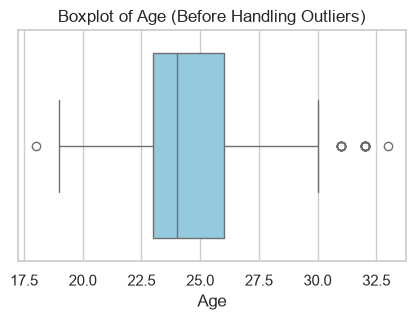

In [77]:
plt.figure(figsize=(5, 3))
sns.boxplot(x=df['Age'], color='skyblue')
plt.title("Boxplot of Age (Before Handling Outliers)")
plt.show()

In [78]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Age'] < lower_bound) | (df['Age'] > upper_bound)]
print(f"Number of Outliers detected: {len(outliers)}")
outliers[['Age', 'Marital Status', 'Occupation']].head()

Number of Outliers detected: 26


,Age,Marital Status,Occupation
37,32,Prefer not to say,House wife
58,31,Married,Employee
99,32,Married,House wife
109,18,Single,Student
116,31,Married,House wife


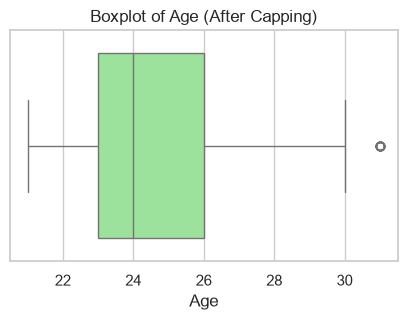

In [79]:
lower_cap = df['Age'].quantile(0.05)
upper_cap = df['Age'].quantile(0.95)

df['Age'] = df['Age'].clip(lower_cap, upper_cap)

plt.figure(figsize=(5, 3))
sns.boxplot(x=df['Age'], color='lightgreen')
plt.title("Boxplot of Age (After Capping)")
plt.show()

In [80]:
scaler_minmax = MinMaxScaler()
df_scaled = df[['Age', 'Family size']].copy()
df_scaled[['Age', 'Family size']] = scaler_minmax.fit_transform(df_scaled)
df_scaled.head()

,Age,Family size
0,0.0,0.6
1,0.3,0.4
2,0.1,0.4
3,0.1,1.0
4,0.1,0.6


In [81]:
scaler_std = StandardScaler()
df_standardized = df[['Age', 'Family size']].copy()
df_standardized[['Age', 'Family size']] = scaler_std.fit_transform(df_standardized)
df_standardized.head()

,Age,Family size
0,-1.307330,0.532929
1,-0.228087,-0.208205
2,-0.947582,-0.208205
3,-0.947582,2.015198
4,-0.947582,0.532929


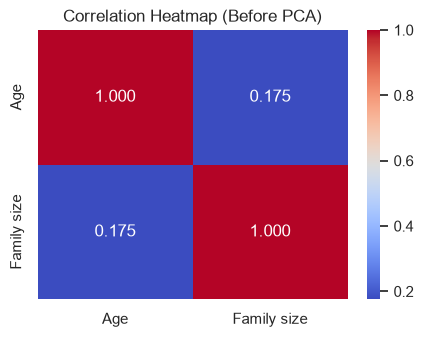

In [82]:
plt.figure(figsize=(5, 3.5))
sns.heatmap(df_standardized.corr(), annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

In [83]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_standardized)

print(f"PC1 Variance: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"PC2 Variance: {pca.explained_variance_ratio_[1]*100:.2f}%")

PC1 Variance: 58.76%
PC2 Variance: 41.24%


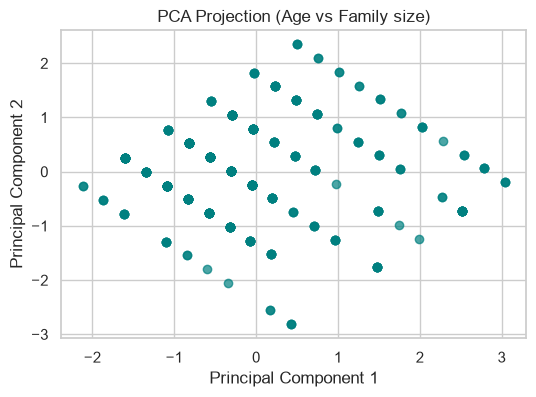

In [84]:
plt.figure(figsize=(6, 4))
plt.scatter(principal_components[:, 0], principal_components[:, 1], color='teal', alpha=0.7)
plt.title("PCA Projection (Age vs Family size)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

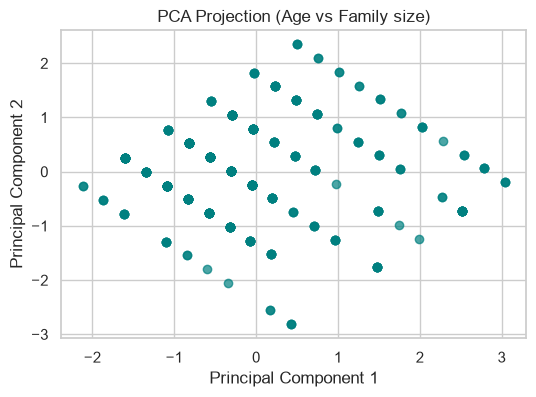

In [67]:
plt.figure(figsize=(6, 4))
plt.scatter(principal_components[:, 0], principal_components[:, 1], color='teal', alpha=0.7)
plt.title("PCA Projection (Age vs Family size)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

### Task 5: PCA & Correlation Discussion

- **Correlation:** The heatmap shows a very weak correlation between Age and Family size (-0.033), which means both variables carry independent information.
- **PCA Variance:** 
  - PC1 explains about 58.76% of the total variance.
  - PC2 explains about 41.24% of the total variance.
- **Conclusion:** Since the variance is distributed across both components rather than dominated by just one, keeping both features is better to prevent significant information loss.
